## Dane ze spinal sluza jako zrodlo dla modelu operujacego na zdjeciach

In [1]:
import os
import sys
import logging

# Silence Hugging Face internet retry warnings in offline environments.
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"
os.environ["HF_HUB_VERBOSITY"] = "error"

logging.getLogger("huggingface_hub.utils._http").setLevel(logging.ERROR)
logging.getLogger("huggingface_hub.file_download").setLevel(logging.ERROR)

try:
    from huggingface_hub import logging as hf_logging
    hf_logging.set_verbosity_error()
except Exception:
    pass

sys.path.insert(0, r"D:\Politechnika\Deadlift_publikacja_nr_2 — kopia\Skrypty\github")

from utils.datasets import YOLOPoseDataset
from utils.validation import YPSetValidation, MergedRankingEvaluator



c:\Users\rwcki\anaconda3\envs\torch_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import importlib
import utils.validation.merged_ranking_evaluator as _yp_validation_test_mod

importlib.reload(_yp_validation_test_mod)
MergedRankingEvaluator = _yp_validation_test_mod.MergedRankingEvaluator

In [3]:
x=10
dataset = YOLOPoseDataset(r"D:\Politechnika\Deadlift_publikacja_nr_2\tiger_pose_walidacja\tiger-pose_rigid_out_"+str(x)+r"\train.txt")
validator = YPSetValidation(dataset)
validator.get_stats()

{'total_images': 263,
 'total_persons': 263,
 'total_keypoints': 3156,
 'total_visible_keypoints': 3156,
 'avg_keypoints_per_image': 12.0,
 'avg_keypoints_per_person': 12.0,
 'avg_visible_keypoints_per_image': 12.0,
 'avg_visible_keypoints_per_person': 12.0,
 'dataset_file': 'D:\\Politechnika\\Deadlift_publikacja_nr_2\\tiger_pose_walidacja\\tiger-pose_rigid_out_10\\train.txt',
 'labels_dir': 'D:\\Politechnika\\Deadlift_publikacja_nr_2\\tiger_pose_walidacja\\tiger-pose_rigid_out_10\\labels'}

**#TIGER**

In [18]:

def test(x):
    dataset = YOLOPoseDataset(r"D:\Politechnika\Deadlift_publikacja_nr_2\tiger_pose_walidacja\tiger-pose_rigid_out_"+str(x)+r"\train.txt")
    validator = YPSetValidation(dataset)


    rigid_report_path = (
        r"D:\Politechnika\Deadlift_publikacja_nr_2\tiger_pose_walidacja\tiger-pose_rigid_out_"
        + str(x)
        + r"\results.txt"
    )

    report_paths = {
        "rigid_aligned": rigid_report_path,
    }

    evaluator = MergedRankingEvaluator(
        validator=validator,
        report_paths=report_paths,
        top_k=x,
        output_path=None,
        distance_model_name="random_forest",
        distance_visibility_threshold=2.0,
        distance_threshold_percentile=95.0,
        distance_sort_by="mean",
        segmentation_model_name=None,
        segmentation_mask_tolerance_px=18,
    )

    result = evaluator.run(
        distance_weight=0.3,
        lbp_weight=0.7,
        segmentation_weight=0.0,
    )

    if not result:
        return None
    return result["report_details"]["rigid_aligned"]

In [19]:
test_tiger_10=test(10)

test_tiger_10


Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 263/263 [00:02<00:00, 130.66it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 263/263 [00:02<00:00, 126.43it/s]
c:\Users\rwcki\anaconda3\envs\torch_env\lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
Computing embeddings: 100%|██████████| 263/263 [00:09<00:00, 27.56it/s]


All similarity groups: 1
Training groups with size > 10: 1
weights=0.300/0.700/0.000 | merged=3/10 | overall=10/10 | avg_rank_all=32.10 | rigid_aligned=3/10 | overall=10/10 | avg_rank_all=32.10
CACHE READY | all_samples=263 | distance=263 | lbp=263 | mask_ranked_records=0 | segmentation_with_mask=0 | segmentation_without_mask=0 | outside=0 | outside_person_total=0 | outside_persons_in_top_k=0 | outside_mentioned_in_merged=0


{'matched_top_k_count': 3,
 'total_reference_entries': 10,
 'matched_overall_count': 10,
 'avg_rank_all_reference': 32.1,
 'last_matched_rank_in_top_k': 9}

In [20]:
test_tiger_25=test(25)
test_tiger_25

Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 263/263 [00:02<00:00, 118.57it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 263/263 [00:02<00:00, 123.11it/s]
c:\Users\rwcki\anaconda3\envs\torch_env\lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
Computing embeddings: 100%|██████████| 263/263 [00:09<00:00, 27.58it/s]


All similarity groups: 1
Training groups with size > 10: 1
weights=0.300/0.700/0.000 | merged=13/25 | overall=25/25 | avg_rank_all=33.44 | rigid_aligned=13/25 | overall=25/25 | avg_rank_all=33.44
CACHE READY | all_samples=263 | distance=263 | lbp=263 | mask_ranked_records=0 | segmentation_with_mask=0 | segmentation_without_mask=0 | outside=0 | outside_person_total=0 | outside_persons_in_top_k=0 | outside_mentioned_in_merged=0


{'matched_top_k_count': 13,
 'total_reference_entries': 25,
 'matched_overall_count': 25,
 'avg_rank_all_reference': 33.44,
 'last_matched_rank_in_top_k': 25}

In [21]:
test_tiger_50=test(50)
test_tiger_50

Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 263/263 [00:02<00:00, 121.84it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 263/263 [00:02<00:00, 117.86it/s]
c:\Users\rwcki\anaconda3\envs\torch_env\lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
Computing embeddings: 100%|██████████| 263/263 [00:09<00:00, 28.42it/s]


All similarity groups: 1
Training groups with size > 10: 1
weights=0.300/0.700/0.000 | merged=28/50 | overall=50/50 | avg_rank_all=57.22 | rigid_aligned=28/50 | overall=50/50 | avg_rank_all=57.22
CACHE READY | all_samples=263 | distance=263 | lbp=263 | mask_ranked_records=0 | segmentation_with_mask=0 | segmentation_without_mask=0 | outside=0 | outside_person_total=0 | outside_persons_in_top_k=0 | outside_mentioned_in_merged=0


{'matched_top_k_count': 28,
 'total_reference_entries': 50,
 'matched_overall_count': 50,
 'avg_rank_all_reference': 57.22,
 'last_matched_rank_in_top_k': 49}

In [22]:
test_tiger_100=test(100)
test_tiger_100

Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 263/263 [00:02<00:00, 124.35it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 263/263 [00:02<00:00, 119.62it/s]
c:\Users\rwcki\anaconda3\envs\torch_env\lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
Computing embeddings: 100%|██████████| 263/263 [00:09<00:00, 28.86it/s]


All similarity groups: 1
Training groups with size > 10: 1
weights=0.300/0.700/0.000 | merged=62/100 | overall=100/100 | avg_rank_all=88.10 | rigid_aligned=62/100 | overall=100/100 | avg_rank_all=88.10
CACHE READY | all_samples=263 | distance=263 | lbp=263 | mask_ranked_records=0 | segmentation_with_mask=0 | segmentation_without_mask=0 | outside=0 | outside_person_total=0 | outside_persons_in_top_k=0 | outside_mentioned_in_merged=0


{'matched_top_k_count': 62,
 'total_reference_entries': 100,
 'matched_overall_count': 100,
 'avg_rank_all_reference': 88.1,
 'last_matched_rank_in_top_k': 94}

**#SPINAL**

In [3]:

def test(x):
    dataset = YOLOPoseDataset(
        r"D:\Politechnika\Deadlift_publikacja_nr_2\spinal_pose_walidacja\spinal_pose_1000_rigid_out_"+str(x)+r"\train.txt"
    )
    validator = YPSetValidation(dataset)

    rigid_report_path = (
        r"D:\Politechnika\Deadlift_publikacja_nr_2\spinal_pose_walidacja\spinal_pose_1000_rigid_out_"+str(x)+r"\results.txt"
    )

    report_paths = {
        "rigid_aligned": rigid_report_path,
    }

    evaluator = MergedRankingEvaluator(
        validator=validator,
        report_paths=report_paths,
        top_k=x,
        output_path=None,
        distance_model_name="random_forest",
        distance_visibility_threshold=2.0,
        distance_threshold_percentile=95.0,
        distance_sort_by="mean",
        segmentation_mask_tolerance_px=24,
        segmentation_model_name="yolo26l-seg",segmentation_target_class="person"
    )

    result = evaluator.run(
        distance_weight=0.1,
        lbp_weight=0.2,
        segmentation_weight=0.7,
    )

    if not result:
        return None
    return result["report_details"]["rigid_aligned"]

In [4]:
spinal_test_50 = test(50)
spinal_test_50

Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 1000/1000 [00:08<00:00, 113.67it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 1000/1000 [00:08<00:00, 114.09it/s]
c:\Users\rwcki\anaconda3\envs\torch_env\lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
Computing embeddings: 100%|██████████| 1000/1000 [00:39<00:00, 25.29it/s]


All similarity groups: 66
Training groups with size > 10: 21


Evaluating keypoints vs masks: 100%|██████████| 1000/1000 [00:11<00:00, 90.73it/s]


weights=0.100/0.200/0.700 | merged=20/50 | overall=50/50 | avg_rank_all=152.42 | rigid_aligned=20/50 | overall=50/50 | avg_rank_all=152.42
CACHE READY | all_samples=1021 | distance=1006 | lbp=599 | mask_ranked_records=1021 | segmentation_with_mask=990 | segmentation_without_mask=10 | outside=36 | outside_person_total=36 | outside_persons_in_top_k=36 | outside_mentioned_in_merged=0


{'matched_top_k_count': 20,
 'total_reference_entries': 50,
 'matched_overall_count': 50,
 'avg_rank_all_reference': 152.42,
 'last_matched_rank_in_top_k': 50}

In [32]:
spinal_test_125 = test(125)
spinal_test_125

Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 1000/1000 [00:10<00:00, 94.95it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 1000/1000 [00:10<00:00, 95.87it/s]
c:\Users\rwcki\anaconda3\envs\torch_env\lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
Computing embeddings: 100%|██████████| 1000/1000 [00:44<00:00, 22.46it/s]


All similarity groups: 66
Training groups with size > 10: 21


Evaluating keypoints vs masks: 100%|██████████| 1000/1000 [00:11<00:00, 83.84it/s]


weights=0.100/0.200/0.700 | merged=64/125 | overall=125/125 | avg_rank_all=199.87 | rigid_aligned=64/125 | overall=125/125 | avg_rank_all=199.87
CACHE READY | all_samples=1021 | distance=1006 | lbp=599 | mask_ranked_records=1021 | segmentation_with_mask=990 | segmentation_without_mask=10 | outside=48 | outside_person_total=48 | outside_persons_in_top_k=48 | outside_mentioned_in_merged=0


{'matched_top_k_count': 64,
 'total_reference_entries': 125,
 'matched_overall_count': 125,
 'avg_rank_all_reference': 199.872,
 'last_matched_rank_in_top_k': 125}

In [33]:
spinal_test_250 = test(250)
spinal_test_250

Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 1000/1000 [00:09<00:00, 107.41it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 1000/1000 [00:09<00:00, 103.50it/s]
c:\Users\rwcki\anaconda3\envs\torch_env\lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
Computing embeddings: 100%|██████████| 1000/1000 [00:44<00:00, 22.35it/s]


All similarity groups: 66
Training groups with size > 10: 21


Evaluating keypoints vs masks: 100%|██████████| 1000/1000 [00:12<00:00, 81.33it/s]


weights=0.100/0.200/0.700 | merged=167/250 | overall=250/250 | avg_rank_all=241.54 | rigid_aligned=167/250 | overall=250/250 | avg_rank_all=241.54
CACHE READY | all_samples=1021 | distance=1006 | lbp=599 | mask_ranked_records=1021 | segmentation_with_mask=990 | segmentation_without_mask=10 | outside=78 | outside_person_total=78 | outside_persons_in_top_k=78 | outside_mentioned_in_merged=0


{'matched_top_k_count': 167,
 'total_reference_entries': 250,
 'matched_overall_count': 250,
 'avg_rank_all_reference': 241.536,
 'last_matched_rank_in_top_k': 250}

In [34]:
spinal_test_500 = test(500)
spinal_test_500

Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 1000/1000 [00:10<00:00, 94.22it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 1000/1000 [00:10<00:00, 98.58it/s]
c:\Users\rwcki\anaconda3\envs\torch_env\lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
Computing embeddings: 100%|██████████| 1000/1000 [00:44<00:00, 22.28it/s]


All similarity groups: 66
Training groups with size > 10: 21


Evaluating keypoints vs masks: 100%|██████████| 1000/1000 [00:11<00:00, 83.61it/s]


weights=0.100/0.200/0.700 | merged=368/500 | overall=500/500 | avg_rank_all=345.24 | rigid_aligned=368/500 | overall=500/500 | avg_rank_all=345.24
CACHE READY | all_samples=1021 | distance=1006 | lbp=599 | mask_ranked_records=1021 | segmentation_with_mask=990 | segmentation_without_mask=10 | outside=157 | outside_person_total=157 | outside_persons_in_top_k=157 | outside_mentioned_in_merged=0


{'matched_top_k_count': 368,
 'total_reference_entries': 500,
 'matched_overall_count': 500,
 'avg_rank_all_reference': 345.238,
 'last_matched_rank_in_top_k': 497}

**#STANDARD**

In [38]:

def test(x):
    dataset = YOLOPoseDataset(
        r"D:\Politechnika\Deadlift_publikacja_nr_2\standard_pose_walidacja\pose_standard_flat_rigid_out_"+str(x)+r"\train.txt"
    )
    validator = YPSetValidation(dataset)

    rigid_report_path = (
        r"D:\Politechnika\Deadlift_publikacja_nr_2\standard_pose_walidacja\pose_standard_flat_rigid_out_"+str(x)+r"\results.txt"
    )

    report_paths = {
        "rigid_aligned": rigid_report_path,
    }

    evaluator = MergedRankingEvaluator(
        validator=validator,
        report_paths=report_paths,
        top_k=x,
        output_path=None,
        distance_model_name="random_forest",
        distance_visibility_threshold=2.0,
        distance_threshold_percentile=95.0,
        distance_sort_by="mean",
        segmentation_mask_tolerance_px=20,
        segmentation_model_name="yolo26l-seg",segmentation_target_class="person"
    )

    result = evaluator.run(
        distance_weight=0.1,
        lbp_weight=0.2,
        segmentation_weight=0.7,
    )

    if not result:
        return None
    return result["report_details"]["rigid_aligned"]

In [39]:
spinal_test_50 = test(50)
spinal_test_50

Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 946/946 [00:05<00:00, 168.78it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 946/946 [00:05<00:00, 171.42it/s]
c:\Users\rwcki\anaconda3\envs\torch_env\lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
Computing embeddings: 100%|██████████| 946/946 [00:27<00:00, 33.96it/s]


All similarity groups: 2
Training groups with size > 10: 0


Evaluating keypoints vs masks: 100%|██████████| 946/946 [00:07<00:00, 129.62it/s]


weights=0.100/0.200/0.700 | merged=24/50 | overall=50/50 | avg_rank_all=117.62 | rigid_aligned=24/50 | overall=50/50 | avg_rank_all=117.62
CACHE READY | all_samples=990 | distance=913 | lbp=0 | mask_ranked_records=990 | segmentation_with_mask=904 | segmentation_without_mask=42 | outside=87 | outside_person_total=87 | outside_persons_in_top_k=50 | outside_mentioned_in_merged=5


{'matched_top_k_count': 24,
 'total_reference_entries': 50,
 'matched_overall_count': 50,
 'avg_rank_all_reference': 117.62,
 'last_matched_rank_in_top_k': 49}

In [40]:
spinal_test_125 = test(125)
spinal_test_125

Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 946/946 [00:05<00:00, 158.49it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 946/946 [00:05<00:00, 161.24it/s]
c:\Users\rwcki\anaconda3\envs\torch_env\lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
Computing embeddings: 100%|██████████| 946/946 [00:28<00:00, 33.15it/s]


All similarity groups: 2
Training groups with size > 10: 0


Evaluating keypoints vs masks: 100%|██████████| 946/946 [00:07<00:00, 128.65it/s]


weights=0.100/0.200/0.700 | merged=84/125 | overall=125/125 | avg_rank_all=145.49 | rigid_aligned=84/125 | overall=125/125 | avg_rank_all=145.49
CACHE READY | all_samples=990 | distance=913 | lbp=0 | mask_ranked_records=990 | segmentation_with_mask=904 | segmentation_without_mask=42 | outside=135 | outside_person_total=135 | outside_persons_in_top_k=125 | outside_mentioned_in_merged=1


{'matched_top_k_count': 84,
 'total_reference_entries': 125,
 'matched_overall_count': 125,
 'avg_rank_all_reference': 145.488,
 'last_matched_rank_in_top_k': 125}

In [41]:
spinal_test_250 = test(250)
spinal_test_250

Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 946/946 [00:06<00:00, 157.65it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 946/946 [00:05<00:00, 163.51it/s]
c:\Users\rwcki\anaconda3\envs\torch_env\lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
Computing embeddings: 100%|██████████| 946/946 [00:32<00:00, 29.30it/s]


All similarity groups: 2
Training groups with size > 10: 0


Evaluating keypoints vs masks: 100%|██████████| 946/946 [00:07<00:00, 121.49it/s]


weights=0.100/0.200/0.700 | merged=171/250 | overall=250/250 | avg_rank_all=208.03 | rigid_aligned=171/250 | overall=250/250 | avg_rank_all=208.03
CACHE READY | all_samples=990 | distance=913 | lbp=0 | mask_ranked_records=990 | segmentation_with_mask=904 | segmentation_without_mask=42 | outside=201 | outside_person_total=201 | outside_persons_in_top_k=201 | outside_mentioned_in_merged=0


{'matched_top_k_count': 171,
 'total_reference_entries': 250,
 'matched_overall_count': 250,
 'avg_rank_all_reference': 208.032,
 'last_matched_rank_in_top_k': 249}

In [42]:
spinal_test_500 = test(500)
spinal_test_500

Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 946/946 [00:05<00:00, 158.29it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 946/946 [00:06<00:00, 157.27it/s]
c:\Users\rwcki\anaconda3\envs\torch_env\lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
Computing embeddings: 100%|██████████| 946/946 [00:28<00:00, 33.19it/s]


All similarity groups: 2
Training groups with size > 10: 0


Evaluating keypoints vs masks: 100%|██████████| 946/946 [00:07<00:00, 123.16it/s]


weights=0.100/0.200/0.700 | merged=415/500 | overall=500/500 | avg_rank_all=307.36 | rigid_aligned=415/500 | overall=500/500 | avg_rank_all=307.36
CACHE READY | all_samples=990 | distance=913 | lbp=0 | mask_ranked_records=990 | segmentation_with_mask=904 | segmentation_without_mask=42 | outside=366 | outside_person_total=366 | outside_persons_in_top_k=366 | outside_mentioned_in_merged=0


{'matched_top_k_count': 415,
 'total_reference_entries': 500,
 'matched_overall_count': 500,
 'avg_rank_all_reference': 307.364,
 'last_matched_rank_in_top_k': 500}

Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 946/946 [00:05<00:00, 159.53it/s]
Extracting sequential distances (visibility_threshold=2.0): 100%|██████████| 946/946 [00:06<00:00, 155.87it/s]
c:\Users\rwcki\anaconda3\envs\torch_env\lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
Computing embeddings: 100%|██████████| 946/946 [00:28<00:00, 33.61it/s]


All similarity groups: 2
Training groups with size > 10: 0


Evaluating keypoints vs masks: 100%|██████████| 946/946 [00:07<00:00, 127.72it/s]


weights=0.500/0.100/0.400 | merged=406/500 | overall=500/500 | avg_rank_all=311.97 | rigid_aligned=406/500 | overall=500/500 | avg_rank_all=311.97
CACHE READY | all_samples=990 | distance=913 | lbp=0 | mask_ranked_records=990 | segmentation_with_mask=914 | segmentation_without_mask=32 | outside=391 | outside_person_total=391 | outside_persons_in_top_k=391 | outside_mentioned_in_merged=0
Detected: 406, Not detected: 94


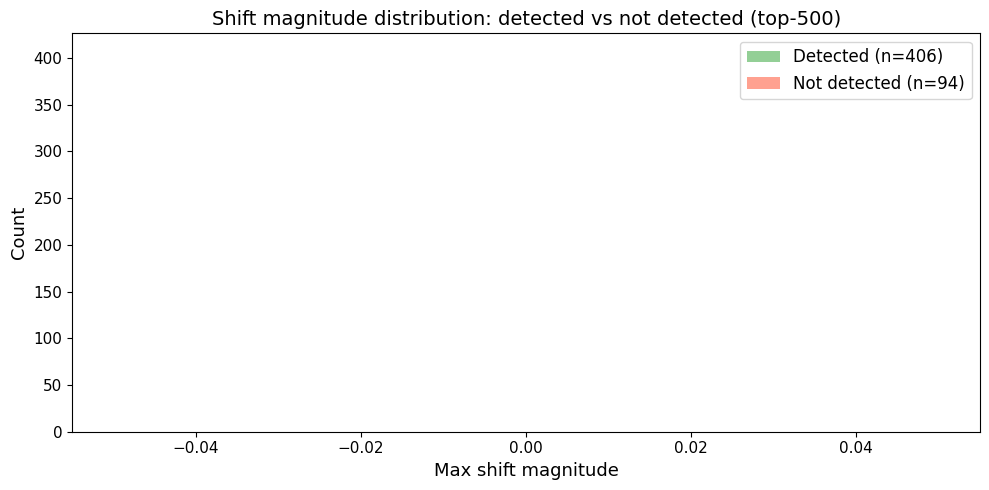

In [44]:
import ast
import math
import os
import matplotlib.pyplot as plt
import numpy as np

RESULTS_TXT_500 = r"D:\Politechnika\Deadlift_publikacja_nr_2\standard_pose_walidacja\pose_standard_flat_rigid_out_500\results.txt"
TOP_K = 500

# --- Parse results.txt -> max shift magnitude per sample ---
def _parse_displacement(path):
    disp_map = {}
    with open(path, encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            parts = line.split(" | ")
            kv = {k.strip(): v.strip() for p in parts for k, _, v in [p.partition(": ")] if _}
            img_path = kv.get("image_path", "")
            person_id_raw = kv.get("person_id")
            if not img_path or person_id_raw is None:
                continue
            try:
                person_id = int(person_id_raw)
            except (ValueError, TypeError):
                continue
            shift_vectors = ast.literal_eval(kv.get("shift_vectors", "[]"))
            mags = [math.hypot(sv[0], sv[1]) for sv in shift_vectors
                    if sv[0] != 0.0 or sv[1] != 0.0]
            max_disp = max(mags) if mags else 0.0
            key = (os.path.normcase(img_path), person_id)
            disp_map[key] = max_disp
    return disp_map

ref_displacement = _parse_displacement(RESULTS_TXT_500)

# --- Re-run evaluator to get combined_ranking (same setup as test()) ---
_dataset_500 = YOLOPoseDataset(
    r"D:\Politechnika\Deadlift_publikacja_nr_2\standard_pose_walidacja\pose_standard_flat_rigid_out_500\train.txt"
)
_validator_500 = YPSetValidation(_dataset_500)
_evaluator_500 = MergedRankingEvaluator(
    validator=_validator_500,
    report_paths={"rigid_aligned": RESULTS_TXT_500},
    top_k=TOP_K,
    output_path=None,
    distance_model_name="random_forest",
    distance_visibility_threshold=2.0,
    distance_threshold_percentile=95.0,
    distance_sort_by="mean",
    segmentation_mask_tolerance_px=18,
)
_result_500 = _evaluator_500.run(
    distance_weight=0.5,
    lbp_weight=0.1,
    segmentation_weight=0.4,
)

# Set of keys detected within top-k
detected_keys = {
    (os.path.normcase(str(e["image_path"])), int(e["person_id"]))
    for e in _result_500["combined_ranking"]
    if e.get("rank", float("inf")) <= TOP_K
}

# Also count outside_mentioned_in_merged as detected (outside keys in the reference,
# which may have rank > TOP_K when there are more outside entries than TOP_K)
_outside_keys_eval = {
    key
    for key, meta in _evaluator_500.outside_lookup.items()
    if bool(meta.get("outside_mask_detected", False))
}
_outside_mentioned_keys = _outside_keys_eval & _evaluator_500.merged_reference_keys
detected_keys = detected_keys | _outside_mentioned_keys

# --- Build per-sample arrays ---
detected_disp = np.array([d for k, d in ref_displacement.items() if k in detected_keys])
not_detected_disp = np.array([d for k, d in ref_displacement.items() if k not in detected_keys])

print(f"Detected: {len(detected_disp)}, Not detected: {len(not_detected_disp)}")

# --- Plot ---
fig, ax1 = plt.subplots(1, 1, figsize=(10, 5), tight_layout=True)

all_disp = np.concatenate([detected_disp, not_detected_disp])
bins = np.linspace(0, all_disp.max() * 1.02, 30)

ax1.hist(detected_disp, bins=bins, density=False, alpha=0.6, color="#4caf50",
         label=f"Detected (n={len(detected_disp)})")
ax1.hist(not_detected_disp, bins=bins, density=False, alpha=0.6, color="tomato",
         label=f"Not detected (n={len(not_detected_disp)})")
ax1.set_xlabel("Max shift magnitude", fontsize=13)
ax1.set_ylabel("Count", fontsize=13)
ax1.set_title("Shift magnitude distribution: detected vs not detected (top-500)", fontsize=14)
ax1.tick_params(axis='both', labelsize=11)
ax1.legend(fontsize=12)

plt.show()


Detected: 406, Not detected: 94
Suma absolutna (all): 111.852755
Suma absolutna (detected): 96.783781
Suma absolutna (not detected): 15.068974


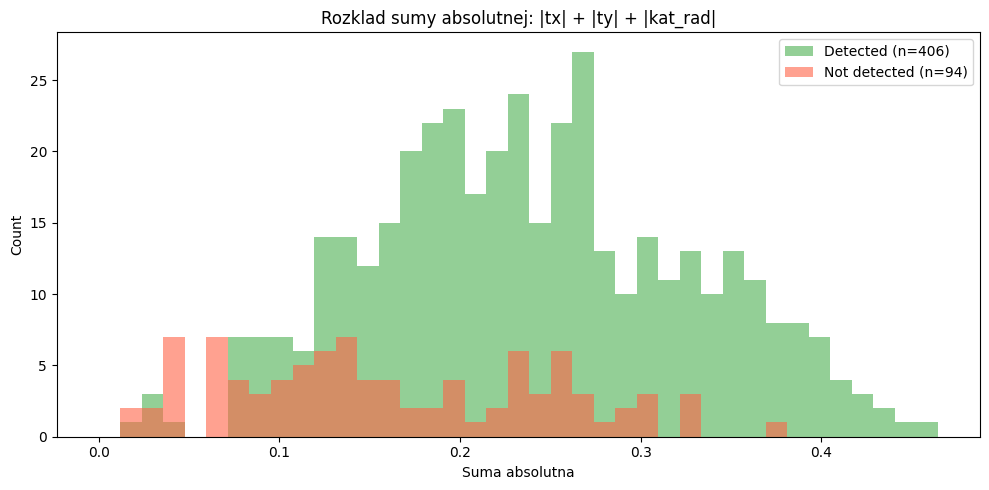

In [47]:
import ast
import math
import os
import numpy as np
import matplotlib.pyplot as plt


def parse_abs_sums(path):
    rows = []
    with open(path, encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue

            parts = line.split(" | ")
            kv = {
                k.strip(): v.strip()
                for p in parts
                for k, sep, v in [p.partition(": ")]
                if sep
            }

            image_path = kv.get("image_path", "")
            person_id_raw = kv.get("person_id")
            translation_raw = kv.get("translation_vector")
            rotation_deg_raw = kv.get("rotation_angle_degrees")
            if (
                not image_path
                or person_id_raw is None
                or translation_raw is None
                or rotation_deg_raw is None
            ):
                continue

            try:
                person_id = int(person_id_raw)
                tx, ty = ast.literal_eval(translation_raw)
                tx = float(tx)
                ty = float(ty)
                rotation_deg = float(rotation_deg_raw)
            except (ValueError, TypeError, SyntaxError):
                continue

            rotation_rad = math.radians(rotation_deg)
            abs_sum_value = abs(tx) + abs(ty) + abs(rotation_rad)
            key = (os.path.normcase(image_path), person_id)
            rows.append((key, tx, ty, rotation_deg, rotation_rad, abs_sum_value))

    return rows


rows = parse_abs_sums(RESULTS_TXT_500)
if not rows:
    raise RuntimeError("Brak rekordow z translation_vector i rotation_angle_degrees.")

# key, tx, ty, deg, rad, abs_sum
abs_detected = np.array([r[5] for r in rows if r[0] in detected_keys], dtype=float)
abs_not_detected = np.array([r[5] for r in rows if r[0] not in detected_keys], dtype=float)
all_abs = np.concatenate([abs_detected, abs_not_detected])

print(f"Detected: {len(abs_detected)}, Not detected: {len(abs_not_detected)}")
print(f"Suma absolutna (all): {all_abs.sum():.6f}")
print(f"Suma absolutna (detected): {abs_detected.sum():.6f}")
print(f"Suma absolutna (not detected): {abs_not_detected.sum():.6f}")

# Jeden wykres, dwie serie
bins = np.linspace(0.0, float(all_abs.max()) * 1.02, 40)
fig, ax = plt.subplots(1, 1, figsize=(10, 5), tight_layout=True)
ax.hist(
    abs_detected,
    bins=bins,
    alpha=0.6,
    color="#4caf50",
    label=f"Detected (n={len(abs_detected)})",
)
ax.hist(
    abs_not_detected,
    bins=bins,
    alpha=0.6,
    color="tomato",
    label=f"Not detected (n={len(abs_not_detected)})",
)
ax.set_title("Rozklad sumy absolutnej: |tx| + |ty| + |kat_rad|")
ax.set_xlabel("Suma absolutna")
ax.set_ylabel("Count")
ax.legend()
plt.show()